# **Support Vector Machine**

In [62]:
from google.colab import files
uploaded=files.upload()

Saving svm_test.csv to svm_test (1).csv


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
df=pd.read_csv('svm_test.csv')

In [81]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0
366,LP002989,Male,No,0,Graduate,Yes,9200,0,98.0,180.0


In [66]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0


In [82]:
df.isnull().sum()

,0
Loan_ID,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


In [83]:
df.duplicated().sum()

np.int64(0)

In [84]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,367.000000,367.000000,362.000000,361.000000
mean,4805.599455,1569.577657,136.132597,342.537396
std,4910.685399,2334.232099,61.366652,65.156643
min,0.000000,0.000000,28.000000,6.000000
25%,2864.000000,0.000000,100.250000,360.000000
50%,3786.000000,1025.000000,125.000000,360.000000
75%,5060.000000,2430.500000,158.000000,360.000000
max,72529.000000,24000.000000,550.000000,480.000000


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 28.8+ KB


In [86]:
df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())


In [87]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])


In [88]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [89]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             367 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         367 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      367 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         367 non-null    float64
 9   Loan_Amount_Term   367 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 28.8+ KB


In [91]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0


In [92]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
text_cols=['Gender','Married','Education','Self_Employed']

for col in text_cols:
  df[col]=le.fit_transform(df[col])

df['Dependents']=df['Dependents'].replace('3+',3).astype(int)

df=df.drop(columns=['Loan_ID'])



In [93]:
df.describe()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000
mean,0.809264,0.634877,0.806540,0.228883,0.100817,4805.599455,1569.577657,135.980926,342.822888
std,0.393417,0.482122,1.065177,0.420687,0.301498,4910.685399,2334.232099,60.959739,64.658402
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,28.000000,6.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,2864.000000,0.000000,101.000000,360.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,3786.000000,1025.000000,125.000000,360.000000
75%,1.000000,1.000000,2.000000,0.000000,0.000000,5060.000000,2430.500000,157.500000,360.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,72529.000000,24000.000000,550.000000,480.000000


In [94]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term'],
      dtype='object')

In [95]:
df['Loan_status']=(df['ApplicantIncome']>(df['LoanAmount']*15)).astype(int)

In [96]:
df['Loan_status'].value_counts()

,count
Loan_status,
1,350
0,17


# **Exploratory Data Analysis**

/tmp/ipykernel_1686/269985821.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Loan_status',palette='Set2')


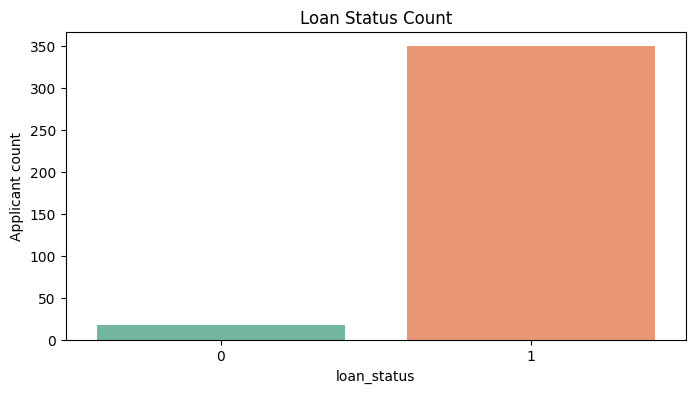

In [99]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x='Loan_status',palette='Set2')
plt.title('Loan Status Count')
plt.xlabel('loan_status')
plt.ylabel('Applicant count')
plt.show()

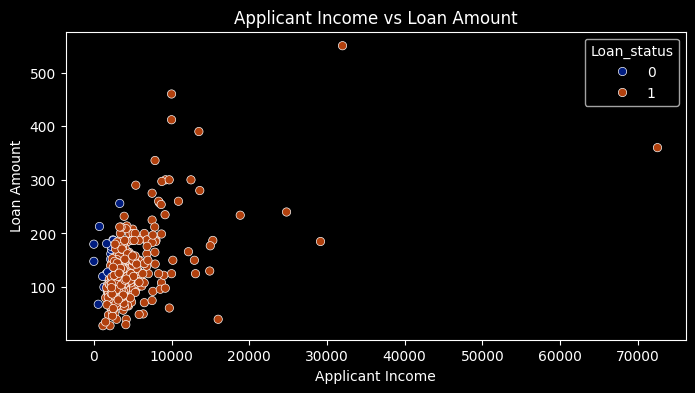

In [109]:
plt.figure(figsize=(8,4))

sns.scatterplot(x='ApplicantIncome',y='LoanAmount',data=df,hue='Loan_status',palette='dark')
plt.title('Applicant Income vs Loan Amount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.show()

# **Training the model**

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

X=df.drop(columns=['Loan_status'])
y=df['Loan_status']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

model=SVC(kernel='linear',C=1.0)
model.fit(X_train_scaled,y_train)

y_pred=model.predict(X_test_scaled)

accuracy=accuracy_score(y_test,y_pred)
print("="*50)
print(f"Accuracy:{accuracy*100:.2f}%")
print("="*50)
print("Classification Report:")
print(classification_report(y_test,y_pred))
# print("="*50)
# print("Confusion Matrix:")
# print(confusion_matrix(y_test,y_pred))
# print("="*50)


Accuracy:93.24%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.17      0.29         6
           1       0.93      1.00      0.96        68

    accuracy                           0.93        74
   macro avg       0.97      0.58      0.63        74
weighted avg       0.94      0.93      0.91        74

